## Methodology Overview

The computation of m-height using the Linear Programming (LP) algorithm is extremely time-consuming, as it requires exhaustive enumeration over all possible combinations of (a,b,X,ψ). Although the LP method provides highly accurate ground-truth results, it is computationally infeasible to generate a large dataset using this approach.

To address this limitation, a Monte Carlo–based approximation method has been applied. Instead of traversing every possible configuration, the Monte Carlo approach randomly samples a limited number of candidate tuples (a,b,X,ψ) and solves the corresponding linear programs. The maximum value among these sampled trials is then used as an approximate m-height. While this method introduces stochastic variability, it enables much faster data generation and scales to tens of thousands of samples.

## 1. Ground-Truth Data (LP, same as in project 1) 

In [12]:
import numpy as np
from itertools import combinations, product
from scipy.optimize import linprog
from tqdm import tqdm
import pickle

In [14]:
def Gen_P_matrix(k, n, rng): #k<n
    P = rng.integers(-100, 101, size=(k, n - k), dtype=np.int16)   # sampling uniform in [-100,100]
    return P


In [16]:
def build_tau_inv(a: int, b: int, X, n: int, m: int) -> np.ndarray:
    X = sorted(set(X))
    tau_inv = np.empty(n, dtype=int)
    tau_inv[a] = 0
    for idx, val in enumerate(X, start=1):
        tau_inv[val] = idx               
    tau_inv[b] = m                       
    Y = sorted(set(range(n)) - {a, b} - set(X))
    for i, j in enumerate(Y, start=m+1):
        tau_inv[j] = i             
    return tau_inv

In [18]:
n = 5
a,b = 2,0
m = 3
X = [1,4]
i = build_tau_inv(a,b,X,n,m) # 
print(i)

[3 1 0 4 2]


In [20]:
def solve_z_lp(a,b,m,X,psi,G):

    k, n = G.shape

    #  tau^{-1}
    tau_i = build_tau_inv(a, b, X, n, m)

    #  target：maximize s0 * v_a  => minimize (-s0*g_a)^T u
    s0 = psi[0]
    c  = -s0 * G[:, a]
   
    A_ub, b_ub = [], []

    # j ∈ X： s_{τ^{-1}(j)} v_j <= s0 v_a   和   s_{τ^{-1}(j)} v_j >= 1
    for j in X:
        sj = psi[tau_i[j]]
        A_ub.append(sj * G[:, j] - s0 * G[:, a])
        b_ub.append(0.0)    # <= 0
        A_ub.append(-sj * G[:, j])
        b_ub.append(-1.0)  # <= -1

    # j ∈ Y： |v_j| <= 1
    Y = sorted(set(range(n)) - {a, b} - set(X))
    for j in Y:
        A_ub.append(G[:, j])
        b_ub.append(1.0)     # v_j <= 1
        A_ub.append(-G[:, j])
        b_ub.append(1.0)     # -v_j <= 1

    A_ub = np.vstack(A_ub) if A_ub else np.zeros((0, k))
    b_ub = np.array(b_ub, dtype=float)

    #  v_b = 1  ->  g_b^T u = 1
    A_eq = G[:, b].reshape(1, k)
    b_eq = np.array([1.0])

    bounds = [(None, None)] * k

    z = linprog(c=c, A_ub=A_ub, b_ub=b_ub, A_eq=A_eq, b_eq=b_eq, bounds=bounds, method="highs")
    
    if z.status == 0:    # optimal
        return -z.fun
    if z.status == 2:    # infeasible
        return 0.0
    if z.status == 3:    # unbounded
        return float('inf')
    
    return float('nan')     


In [22]:
def m_height_calc(n, k, m, G):
    max_ = -np.inf
    for a in range(n):
        for b in range(n):
            if a == b: 
                continue
            x = [i for i in range(n) if i not in (a, b)]
            for X in combinations(x, m-1):
                for psi in product([-1, 1], repeat=m):
                    z = solve_z_lp(a, b, m, X, psi, G)  #fixed (a,b,X,psi) 
                    if z == float('inf'):
                        return float('inf')
                    if z > max_:
                        max_ = z
    return max_


In [24]:
def Gen_one_sample_LP(n, k, m, rng):

    P = Gen_P_matrix(k, n, rng)
    G = np.hstack([np.eye(k), P])
    m_height = m_height_calc(n, k, m, G)
    return m_height, P

## 2. Monte carlo

In [27]:
import numpy as np
from scipy.optimize import linprog
from tqdm import tqdm
import pickle


def build_G(k, n, P):
    return np.hstack([np.eye(k), P])

def lp_objective_value(G, a, b, Y, s0=1.0):
    k, n = G.shape
    c = -(s0 * G[:, a])
    A_eq = np.array([G[:, b]])
    b_eq = np.array([1.0])
    A_ub, b_ub = [], []
    for j in Y:
        A_ub.append(G[:, j]); b_ub.append(1.0)
        A_ub.append(-G[:, j]); b_ub.append(1.0)
    A_ub, b_ub = np.array(A_ub), np.array(b_ub)
    res = linprog(c, A_ub=A_ub, b_ub=b_ub, A_eq=A_eq, b_eq=b_eq,
                  bounds=[(None, None)] * k, method="highs")
    if not res.success:
        return None
    return -res.fun

def compute_mheight_lp_sampled(G, m, trials=128, rng=None):
    if rng is None:
        rng = np.random.default_rng()
    k, n = G.shape
    cols = np.arange(n)
    best = 1.0
    for _ in range(trials):
        a = rng.integers(0, n)
        b = rng.integers(0, n - 1)
        if b >= a:
            b += 1
        others = np.setdiff1d(cols, [a, b])
        if m > 1:
            if len(others) < (m - 1):
                continue
            X = rng.choice(others, size=m - 1, replace=False)
        else:
            X = np.array([], dtype=int)
        Y = np.setdiff1d(others, X)
        val = lp_objective_value(G, a, b, Y, s0=1.0)
        if val is not None and val > best:
            best = val
    return float(best)



In [13]:
def Gen_one_sample_MC(n, k, m,P, trials=16, rng=None):
    if rng is None:
        rng = np.random.default_rng()
    P = Gen_P_matrix(k, n, rng)
    G = build_G(k, n, P)
    m_height_MC = compute_mheight_lp_sampled(G, m, trials=trials, rng=rng)
    return m_height_MC

## 3. Samples generation

In [15]:
NUM_SAMPLES = 500
k_space = [4, 5, 6]  
n = 9
LP_inputs, LP_outputs = [], []
MC_inputs, MC_outputs = [], []

print(f"Generating {NUM_SAMPLES} matched (LP, MC) samples ...")
rng = np.random.default_rng(42)  # fixed random

for _ in tqdm(range(NUM_SAMPLES)):
    k = int(rng.choice(k_space))
    m = int(rng.integers(2, max(3, n - k + 1)))

    seed = rng.integers(0, 1_000_000_000)
    sub_rng = np.random.default_rng(seed)
    # LP ground truth
    m_height_LP, P = Gen_one_sample_LP(n, k, m, sub_rng)
    # Monte Carlo approximation
    m_height_MC = Gen_one_sample_MC(n, k, m, P, trials=16, rng=sub_rng)

    # save all input data and labels
    LP_inputs.append([n, k, m, P])
    LP_outputs.append(float(m_height_LP))

    MC_inputs.append([n, k, m, P])
    MC_outputs.append(float(m_height_MC))

print("Generation complete.")
print(f"Saved {len(LP_inputs)} pairs of matched samples.")


with open("LP_inputs.pkl", "wb") as f:
    pickle.dump(LP_inputs, f)
with open("LP_outputs.pkl", "wb") as f:
    pickle.dump(LP_outputs, f)
with open("MC_inputs.pkl", "wb") as f:
    pickle.dump(MC_inputs, f)
with open("MC_outputs.pkl", "wb") as f:
    pickle.dump(MC_outputs, f)

print("Saved LP_inputs.pkl / LP_outputs.pkl / MC_inputs.pkl / MC_outputs.pkl")

Generating 500 matched (LP, MC) samples ...


100%|█████████████████████████████████████████| 500/500 [59:11<00:00,  7.10s/it]

Generation complete.
Saved 500 pairs of matched samples.
Saved LP_inputs.pkl / LP_outputs.pkl / MC_inputs.pkl / MC_outputs.pkl


## 4. Clean the data

all the inf values will be removed

In [18]:
import pickle
import numpy as np

with open("LP_inputs.pkl", "rb") as f:
    LP_inputs = pickle.load(f)
with open("LP_outputs.pkl", "rb") as f:
    LP_outputs = pickle.load(f)
with open("MC_inputs.pkl", "rb") as f:
    MC_inputs = pickle.load(f)
with open("MC_outputs.pkl", "rb") as f:
    MC_outputs = pickle.load(f)

print(f"Loaded: LP={len(LP_inputs)}, MC={len(MC_inputs)}")


def is_finite(x):
    """check if the value is nan or inf"""
    if isinstance(x, (float, np.floating)):
        return np.isfinite(x)
    try:
        return np.isfinite(float(x))
    except Exception:
        return False

# alignment filtering：if either the LP or MC results contain inf, we remove the corresponding rows from both datasets.

clean_LP_inputs, clean_LP_outputs = [], []
clean_MC_inputs, clean_MC_outputs = [], []

for lp_inp, lp_out, mc_inp, mc_out in zip(LP_inputs, LP_outputs, MC_inputs, MC_outputs):
    if not (is_finite(lp_out) and is_finite(mc_out)):
        continue  
    clean_LP_inputs.append(lp_inp)
    clean_LP_outputs.append(float(lp_out))
    clean_MC_inputs.append(mc_inp)
    clean_MC_outputs.append(float(mc_out))


total = len(LP_inputs)
remaining = len(clean_LP_inputs)
removed = total - remaining
print(f"remove {removed}  containing 'inf/nan' samples")

# save data

with open("LP_inputs_clean.pkl", "wb") as f:
    pickle.dump(clean_LP_inputs, f)
with open("LP_outputs_clean.pkl", "wb") as f:
    pickle.dump(clean_LP_outputs, f)
with open("MC_inputs_clean.pkl", "wb") as f:
    pickle.dump(clean_MC_inputs, f)
with open("MC_outputs_clean.pkl", "wb") as f:
    pickle.dump(clean_MC_outputs, f)

print("cleaned data has been saved as *_clean.pkl file。")


Loaded: LP=500, MC=500
remove 26  containing 'inf/nan' samples
cleaned data has been saved as *_clean.pkl file。


## 5. Use different machine learning method to calibrate the MC-created data

Before applying ML models for calibration, it’s important first to examine the distributions of the LP and Monte Carlo results. By looking at their histograms, we can check whether the two methods operate on the same numerical scale and whether any outliers or extreme skew exist. Large mismatches in magnitude or spread could lead to unstable or biased calibration. This preliminary step ensures that the data are clean, comparable, and suitable for reliable model fitting. Since the log2 will be used in NN to calculate loss, we will use log2 of m-height for calibration as well.

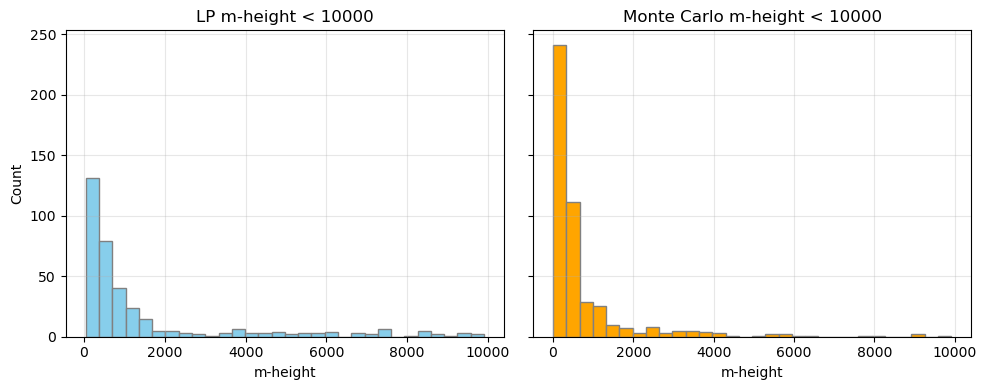

In [21]:
import matplotlib.pyplot as plt
import numpy as np

# filter out large values
lp_filtered = [x for x in clean_LP_outputs if x < 10000]
mc_filtered = [x for x in clean_MC_outputs if x < 10000]

fig, axes = plt.subplots(1, 2, figsize=(10, 4), sharey=True)

axes[0].hist(lp_filtered, bins=30, color='skyblue', edgecolor='gray')
axes[0].set_title("LP m-height < 10000")
axes[0].set_xlabel("m-height")
axes[0].set_ylabel("Count")
axes[0].grid(alpha=0.3)

axes[1].hist(mc_filtered, bins=30, color='orange', edgecolor='gray')
axes[1].set_title("Monte Carlo m-height < 10000")
axes[1].set_xlabel("m-height")
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()



Correlation (log2 scale) = 0.6570
Mean Absolute Error (log2 scale) = 2.2686


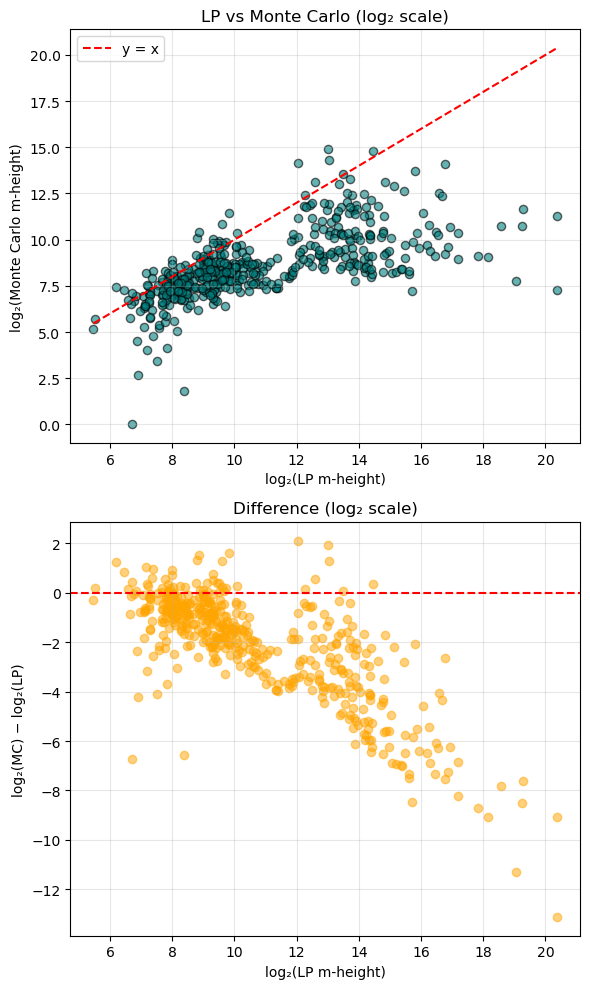

In [22]:
import pickle
import numpy as np
import matplotlib.pyplot as plt


with open("LP_outputs_clean.pkl", "rb") as f:
    lp_outputs = np.array(pickle.load(f))
with open("MC_outputs_clean.pkl", "rb") as f:
    mc_outputs = np.array(pickle.load(f))


mask = np.isfinite(lp_outputs) & np.isfinite(mc_outputs) & (lp_outputs > 0) & (mc_outputs > 0)
lp = lp_outputs[mask]
mc = mc_outputs[mask]


lp_log = np.log2(lp)
mc_log = np.log2(mc)


corr = np.corrcoef(lp_log, mc_log)[0, 1]
mae = np.mean(np.abs(lp_log - mc_log))
print(f"Correlation (log2 scale) = {corr:.4f}")
print(f"Mean Absolute Error (log2 scale) = {mae:.4f}")


fig, axes = plt.subplots(2, 1, figsize=(6, 10))


axes[0].scatter(lp_log, mc_log, alpha=0.6, color='teal', edgecolor='k', s=35)
axes[0].plot(
    [lp_log.min(), lp_log.max()],
    [lp_log.min(), lp_log.max()],
    'r--', label="y = x"
)
axes[0].set_xlabel("log₂(LP m-height)")
axes[0].set_ylabel("log₂(Monte Carlo m-height)")
axes[0].set_title("LP vs Monte Carlo (log₂ scale)")
axes[0].legend()
axes[0].grid(alpha=0.3)


axes[1].scatter(lp_log, mc_log - lp_log, alpha=0.5, color='orange')
axes[1].axhline(0, color='r', linestyle='--')
axes[1].set_xlabel("log₂(LP m-height)")
axes[1].set_ylabel("log₂(MC) − log₂(LP)")
axes[1].set_title("Difference (log₂ scale)")
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()



#### 5.1 linear regression

#### 5.1.1 LR with only MC

This log–log linear model can only capture a simple linear correlation between the LP and MC m-heights： log_mheight_LP = a * log_mheight_MC + b, we use this as a baseline and later compare it with more advanced methods to evaluate the performance improvements.

In [26]:
with open("LP_inputs_clean.pkl", "rb") as f:
    LP_inputs = pickle.load(f)
with open("LP_outputs_clean.pkl", "rb") as f:
    LP_outputs = pickle.load(f)
with open("MC_inputs_clean.pkl", "rb") as f:
    MC_inputs = pickle.load(f)
with open("MC_outputs_clean.pkl", "rb") as f:
    MC_outputs = pickle.load(f)

=== Log-Log Calibration ===
log2(y_lp) ≈ 0.9993 * log2(y_mc) + 2.1223
Train R² = 0.4251, MAE = 1.6386
Val   R² = 0.4420, MAE = 1.7166


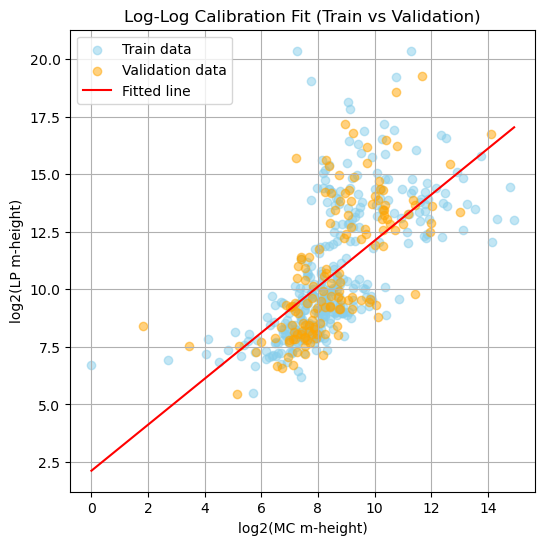

In [27]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error
from sklearn.model_selection import train_test_split


y_lp = np.array(clean_LP_outputs, dtype=float)
y_mc = np.array(clean_MC_outputs, dtype=float)

eps = 1e-6
log_lp = np.log2(np.clip(y_lp, eps, None))
log_mc = np.log2(np.clip(y_mc, eps, None))

#split the train-valid dataset
X_train, X_val, y_train, y_val = train_test_split(log_mc.reshape(-1, 1), log_lp, test_size=0.3, random_state=42)


reg = LinearRegression()
reg.fit(X_train, y_train)


y_train_pred = reg.predict(X_train)
y_val_pred = reg.predict(X_val)

r2_train = r2_score(y_train, y_train_pred)
mae_train = mean_absolute_error(y_train, y_train_pred)

r2_val = r2_score(y_val, y_val_pred)
mae_val = mean_absolute_error(y_val, y_val_pred)

print("=== Log-Log Calibration ===")
print(f"log2(y_lp) ≈ {reg.coef_[0]:.4f} * log2(y_mc) + {reg.intercept_:.4f}")
print(f"Train R² = {r2_train:.4f}, MAE = {mae_train:.4f}")
print(f"Val   R² = {r2_val:.4f}, MAE = {mae_val:.4f}")


plt.figure(figsize=(6,6))
plt.scatter(X_train, y_train, alpha=0.5, color='skyblue', label="Train data")
plt.scatter(X_val, y_val, alpha=0.5, color='orange', label="Validation data")
plt.plot(
    np.linspace(min(log_mc), max(log_mc), 100).reshape(-1, 1),
    reg.predict(np.linspace(min(log_mc), max(log_mc), 100).reshape(-1, 1)),
    'r', label="Fitted line"
)
plt.xlabel("log2(MC m-height)")
plt.ylabel("log2(LP m-height)")
plt.title("Log-Log Calibration Fit (Train vs Validation)")
plt.legend()
plt.grid(True)
plt.show()



#### 5.1.2 LR with more features(use the function of extract_P_features )

Since the matrix 𝑃 strongly influences the resulting m-height, we extract several statistical features to summarize its overall characteristics.
Directly using the entire matrix as model input would be inefficient and high-dimensional, so we instead compute compact summary features such as min,max.... in the following function. We alse add n,m,k as input features

In [30]:

def extract_P_features_simple_version(P):
    feats = []
    feats.append(np.mean(P))
    feats.append(np.std(P))
    feats.append(np.max(P))
    feats.append(np.min(P))
    feats.append(np.median(P))
    feats.append(np.linalg.norm(P, 'fro')) #Frobenius norm — measures the overall magnitude (energy) of the matrix.
    feats.append(np.mean(np.abs(P)))        
    feats.append(np.mean(np.var(P, axis=0)))   #Column-wise and row-wise variance averages
    feats.append(np.mean(np.var(P, axis=1)))  
    return feats


In [29]:
import numpy as np
from scipy.stats import skew, kurtosis

def extract_P_features(P):

    P = np.asarray(P, dtype=np.float32)
    feats = []
 
    feats.append(np.mean(P))                     # mean
    feats.append(np.std(P))                      # std
    feats.append(np.max(P))                      # max
    feats.append(np.min(P))                      # min
    feats.append(np.median(P))                   # median
    feats.append(np.mean(np.abs(P)))             # mean absolute value
    feats.append(np.linalg.norm(P, 'fro'))       # Frobenius norm
 
    feats.append(np.mean(np.var(P, axis=0)))     # column-wise variance mean
    feats.append(np.mean(np.var(P, axis=1)))     # row-wise variance mean
    feats.append(np.std(np.var(P, axis=0)))      # column variance std
    feats.append(np.std(np.var(P, axis=1)))      # row variance std

    feats.append(skew(P.flatten()))              # skewness
    feats.append(kurtosis(P.flatten()))          # kurtosis
    

    feats.append(np.linalg.norm(P, 1))           # L1 norm
    feats.append(np.linalg.norm(P, np.inf))      # max-row-sum norm
    feats.append(np.max(P) / (np.abs(np.min(P)) + 1e-8))  # max/min ratio
    feats.append(np.std(P) / (np.abs(np.mean(P)) + 1e-8)) # coeff of variation
    try:
        s = np.linalg.svd(P, compute_uv=False)
        s_sorted = np.sort(s)[::-1]
        feats.append(s_sorted[0])                # largest singular value
        feats.append(np.sum(s_sorted))            # spectral sum (energy)
        feats.append(np.std(s_sorted))            # singular value spread
    except np.linalg.LinAlgError:
        feats += [0.0, 0.0, 0.0]                 # fallback for degenerate P

    # pad to square for symmetry diff
    if P.shape[0] != P.shape[1]:
        pad = np.zeros((max(P.shape), max(P.shape)), dtype=np.float32)
        pad[:P.shape[0], :P.shape[1]] = P
        P_square = pad
    else:
        P_square = P
    feats.append(np.mean(np.abs(P_square - P_square.T)))   # asymmetry measure
    feats.append(np.sum(np.abs(P) < 1e-2) / P.size)        # sparsity ratio

    return feats


In [32]:
with open("LP_inputs_clean.pkl", "rb") as f:
    LP_inputs = pickle.load(f)
with open("LP_outputs_clean.pkl", "rb") as f:
    LP_outputs = pickle.load(f)
with open("MC_inputs_clean.pkl", "rb") as f:
    MC_inputs = pickle.load(f)
with open("MC_outputs_clean.pkl", "rb") as f:
    MC_outputs = pickle.load(f)

Final usable samples: 474
Feature dimension: 26

Linear Regression
Train R² = 0.7826, MAE = 0.9780
Valid R² = 0.7708, MAE = 1.1064


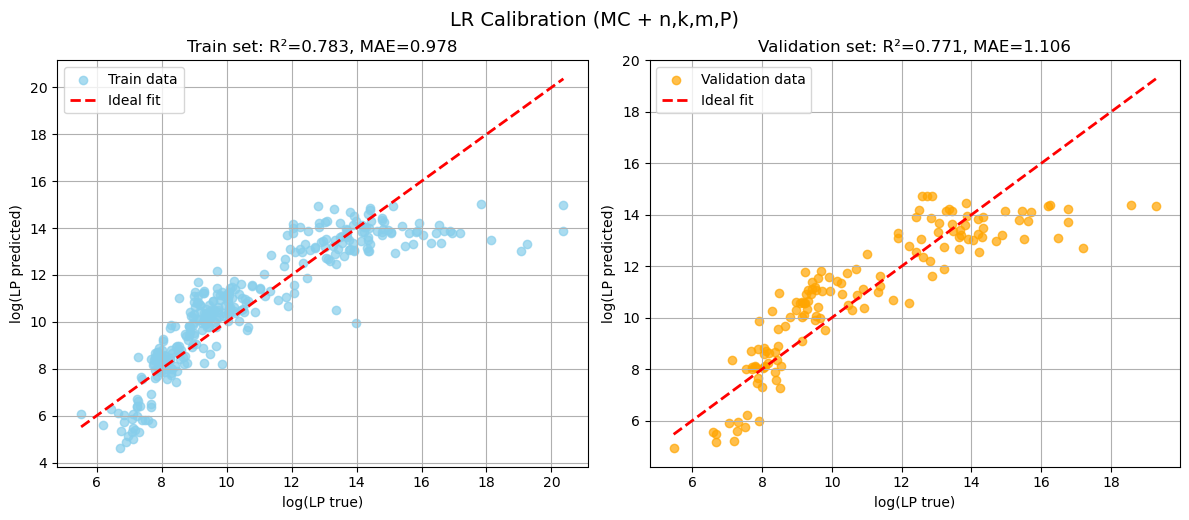

Saved calibration_model_lr.pkl


In [33]:
from sklearn.linear_model import LinearRegression


X, y = [], []
for lp_inp, lp_out, mc_inp, mc_out in zip(LP_inputs, LP_outputs, MC_inputs, MC_outputs):
    n, k, m, P = lp_inp
    #extract features
    p_feats = extract_P_features(P)
    x_vec = [np.log2(mc_out), n, k, m] + p_feats # add P features + n,m,k valuse
    X.append(x_vec)
    y.append(np.log2(lp_out))

X = np.array(X)
y = np.array(y)

print(f"Final usable samples: {len(y)}")
print(f"Feature dimension: {X.shape[1]}")


X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.3, random_state=42)


reg = LinearRegression()
reg.fit(X_train, y_train)

y_train_pred = reg.predict(X_train)
y_val_pred = reg.predict(X_val)

r2_train = r2_score(y_train, y_train_pred)
mae_train = mean_absolute_error(y_train, y_train_pred)
r2_val = r2_score(y_val, y_val_pred)
mae_val = mean_absolute_error(y_val, y_val_pred)

print("\nLinear Regression")
print(f"Train R² = {r2_train:.4f}, MAE = {mae_train:.4f}")
print(f"Valid R² = {r2_val:.4f}, MAE = {mae_val:.4f}")


plt.figure(figsize=(12,5))

# training test
plt.subplot(1,2,1)
plt.scatter(y_train, y_train_pred, alpha=0.7, color='skyblue', label='Train data')
plt.plot([min(y_train), max(y_train)], [min(y_train), max(y_train)], 'r--', lw=2, label='Ideal fit')
plt.xlabel("log(LP true)")
plt.ylabel("log(LP predicted)")
plt.title(f"Train set: R²={r2_train:.3f}, MAE={mae_train:.3f}")
plt.legend()
plt.grid(True)

# test set
plt.subplot(1,2,2)
plt.scatter(y_val, y_val_pred, alpha=0.7, color='orange', label='Validation data')
plt.plot([min(y_val), max(y_val)], [min(y_val), max(y_val)], 'r--', lw=2, label='Ideal fit')
plt.xlabel("log(LP true)")
plt.ylabel("log(LP predicted)")
plt.title(f"Validation set: R²={r2_val:.3f}, MAE={mae_val:.3f}")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.suptitle("LR Calibration (MC + n,k,m,P)", fontsize=14, y=1.03)
plt.show()

with open("calibration_model_lr.pkl", "wb") as f:
    pickle.dump(reg, f)

print("Saved calibration_model_lr.pkl")


 GBDT Calibration (train/val split) ===
Train R² = 0.9731, MAE = 0.3583
Valid R² = 0.7889, MAE = 0.9754


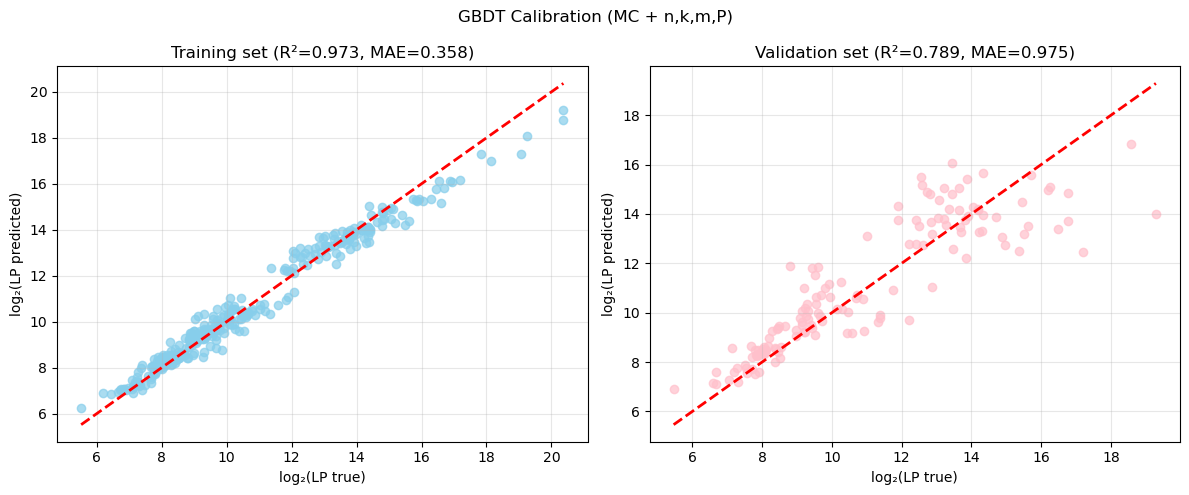

Saved calibration_model_gbdt.pkl


In [34]:
import numpy as np
import pickle
import matplotlib.pyplot as plt
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import r2_score, mean_absolute_error
from sklearn.model_selection import train_test_split


gbdt = GradientBoostingRegressor(
    n_estimators=100,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.7,
    random_state=42
)
gbdt.fit(X_train, y_train)

y_train_pred = gbdt.predict(X_train)
r2_train = r2_score(y_train, y_train_pred)
mae_train = mean_absolute_error(y_train, y_train_pred)


y_val_pred = gbdt.predict(X_val)
r2_val = r2_score(y_val, y_val_pred)
mae_val = mean_absolute_error(y_val, y_val_pred)

print("\n GBDT Calibration (train/val split) ===")
print(f"Train R² = {r2_train:.4f}, MAE = {mae_train:.4f}")
print(f"Valid R² = {r2_val:.4f}, MAE = {mae_val:.4f}")



plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.scatter(y_train, y_train_pred, alpha=0.7, color='skyblue')
plt.plot([min(y_train), max(y_train)], [min(y_train), max(y_train)], 'r--', lw=2)
plt.xlabel("log₂(LP true)")
plt.ylabel("log₂(LP predicted)")
plt.title(f"Training set (R²={r2_train:.3f}, MAE={mae_train:.3f})")
plt.grid(alpha=0.3)


plt.subplot(1,2,2)
plt.scatter(y_val, y_val_pred, alpha=0.7, color='pink')
plt.plot([min(y_val), max(y_val)], [min(y_val), max(y_val)], 'r--', lw=2)
plt.xlabel("log₂(LP true)")
plt.ylabel("log₂(LP predicted)")
plt.title(f"Validation set (R²={r2_val:.3f}, MAE={mae_val:.3f})")
plt.grid(alpha=0.3)

plt.suptitle("GBDT Calibration (MC + n,k,m,P)")
plt.tight_layout()
plt.show()

#save the model
with open("calibration_model_gbdt.pkl", "wb") as f:
    pickle.dump(gbdt, f)

print("Saved calibration_model_gbdt.pkl")


#### SVR

Train R² = 0.8855, MAE = 0.4492
Valid R² = 0.7420, MAE = 1.1476


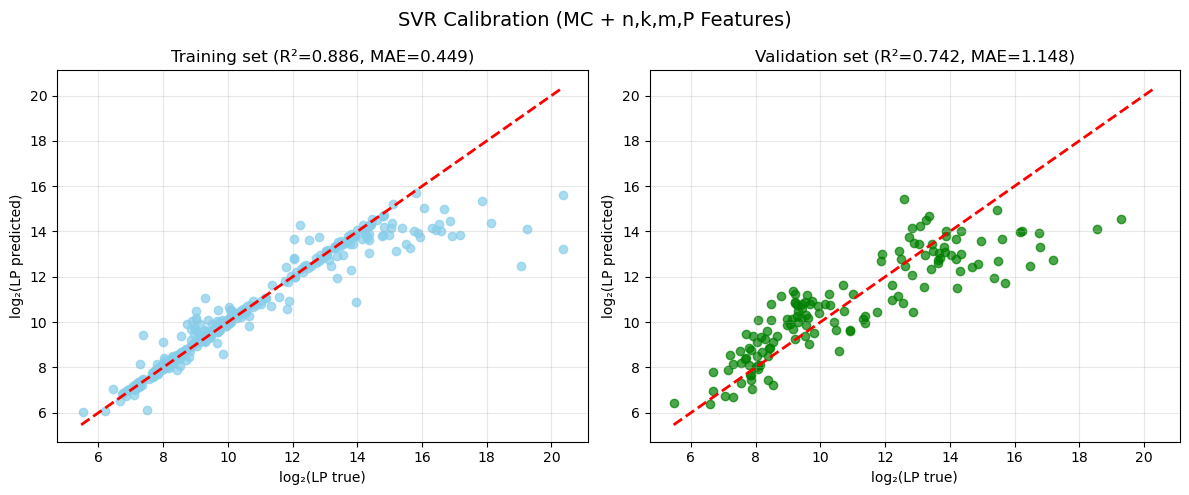

Saved calibration_model_svr.pkl


In [36]:

from sklearn.svm import SVR
from sklearn.metrics import r2_score, mean_absolute_error
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline



svr_model = make_pipeline(
    StandardScaler(),
    SVR(kernel='rbf', C=5.0, epsilon=0.1, gamma='auto')
)
svr_model.fit(X_train, y_train)


y_pred_train = svr_model.predict(X_train)
y_pred_val = svr_model.predict(X_val)


r2_train = r2_score(y_train, y_pred_train)
mae_train = mean_absolute_error(y_train, y_pred_train)
r2_val = r2_score(y_val, y_pred_val)
mae_val = mean_absolute_error(y_val, y_pred_val)


print(f"Train R² = {r2_train:.4f}, MAE = {mae_train:.4f}")
print(f"Valid R² = {r2_val:.4f}, MAE = {mae_val:.4f}")


fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].scatter(y_train, y_pred_train, c='skyblue', alpha=0.7)
axes[0].plot([min(y), max(y)], [min(y), max(y)], 'r--', lw=2)
axes[0].set_title(f"Training set (R²={r2_train:.3f}, MAE={mae_train:.3f})")
axes[0].set_xlabel("log₂(LP true)")
axes[0].set_ylabel("log₂(LP predicted)")
axes[0].grid(alpha=0.3)
axes[1].scatter(y_val, y_pred_val, c='green', alpha=0.7)
axes[1].plot([min(y), max(y)], [min(y), max(y)], 'r--', lw=2)
axes[1].set_title(f"Validation set (R²={r2_val:.3f}, MAE={mae_val:.3f})")
axes[1].set_xlabel("log₂(LP true)")
axes[1].set_ylabel("log₂(LP predicted)")
axes[1].grid(alpha=0.3)
plt.suptitle("SVR Calibration (MC + n,k,m,P Features)", fontsize=14)
plt.tight_layout()
plt.show()

with open("calibration_model_svr.pkl", "wb") as f:
    pickle.dump(svr_model, f)
print("Saved calibration_model_svr.pkl")


## 6. Generate 20000 samples with MC

In [38]:
import numpy as np
import pickle
from tqdm import tqdm

def generate_and_calibrate(num_samples, trials=32, seed=42):
    rng = np.random.default_rng(seed)

    nkmp_list = []       
    mheights_list = []  

    print(f"Generating and calibrating {num_samples} Monte Carlo samples...")

    # feature generation
    feature_X = []
    P_list = []

    for _ in tqdm(range(num_samples)):
        n = 9
        k = rng.choice([4, 5, 6])
        m = rng.integers(2, n - k + 1)

        P = Gen_P_matrix(k, n, rng)
        P_list.append(P)

        m_height_MC = Gen_one_sample_MC(n, k, m, P, trials=trials, rng=rng)

       
        p_feats = extract_P_features(P)
        x_vec = [np.log2(m_height_MC), n, k, m] + p_feats
        feature_X.append(x_vec)

    X = np.array(feature_X, dtype=float)

    #load gbdt
    try:
        with open("calibration_model_gbdt.pkl", "rb") as f:
            gbdt = pickle.load(f)
    except FileNotFoundError:
        print("Error: calibration_model_gbdt.pkl not found!")
        return None

    log_lp_pred = gbdt.predict(X)
    lp_pred = np.power(2, log_lp_pred)  


    for i in range(num_samples):
        n = int(X[i, 1])
        k = int(X[i, 2])
        m = int(X[i, 3])
        P = P_list[i]
        nkmp_list.append((n, k, m, P))
        mheights_list.append(lp_pred[i])

    #save n,k,m,P
    with open("MC_calibrated_n_k_m_P.pkl", "wb") as f:
        pickle.dump(nkmp_list, f)

    # save m-height calibrated
    with open("MC_calibrated_mheights.pkl", "wb") as f:
        pickle.dump(np.array(mheights_list, dtype=np.float32), f)

    print(f"✅ Saved inputs to 'MC_calibrated_n_k_m_P.pkl'")
    print(f"✅ Saved calibrated m-heights to 'MC_calibrated_mheights.pkl'")
    print(f"Total samples: {num_samples}")


In [39]:
data = generate_and_calibrate(num_samples=20000)


Generating and calibrating 20000 Monte Carlo samples...


100%|█████████████████████████████████████| 20000/20000 [08:26<00:00, 39.48it/s]


✅ Saved inputs to 'MC_calibrated_n_k_m_P.pkl'
✅ Saved calibrated m-heights to 'MC_calibrated_mheights.pkl'
Total samples: 20000


## 7 Train different NN

###  7.1 Dense

compared to version 1 in project 1, here a more detailed P features are added as inputs

In [31]:
def padding_one_P(P,k,n = 9):
    P = np.asarray(P, np.float32)  # shape: k × (n-k)
    P_ = np.zeros((6, 5), dtype=np.float32)
    P_[:k, :n-k] = P
    return P_

In [44]:
import pickle
import numpy as np
from sklearn.model_selection import train_test_split

with open("DS-2-Train-mheights", "rb") as f:
    teacher_mheights = pickle.load(f)    # list or array of floats (true LP m-height)

with open("DS-2-Train-n_k_m_P", "rb") as f:
    teacher_nkmP = pickle.load(f) 
teacher_X, teacher_y = [], []
for (n, k, m, P), mh in zip(teacher_nkmP, teacher_mheights):
    P_pad = padding_one_P(P, k, n)
    P_feats = extract_P_features(P_pad)# shape (6,5)
    x_vec = np.concatenate(([n, k, m], P_pad.flatten(),P_feats))
    teacher_X.append(x_vec)
    teacher_y.append(np.log2(mh))
teacher_X = np.array(teacher_X, dtype=np.float32)
teacher_y = np.array(teacher_y, dtype=np.float32)

print(f"Teacher dataset: {teacher_X.shape}, {teacher_y.shape}")

with open("MC_calibrated_n_k_m_P.pkl", "rb") as f:
    nkmp_data = pickle.load(f)   # list of tuples: (n, k, m, P)
with open("MC_calibrated_mheights.pkl", "rb") as f:
    mheights = pickle.load(f)  
    
my_X, my_y = [], []
for (n, k, m, P), mh in zip(nkmp_data, mheights):
    P_pad = padding_one_P(P, k, n) 
    P_feats = extract_P_features(P_pad)
    x_vec = np.concatenate(([n, k, m], P_pad.flatten(),P_feats))  
    my_X.append(x_vec)
    my_y.append(np.log2(max(mh, 1e-6))) 
    
my_X = np.array(my_X, dtype=np.float32)
my_y = np.array(my_y, dtype=np.float32)

print(f"My generated dataset: {my_X.shape}, {my_y.shape}")

X_train_teacher, X_val_teacher, y_train_teacher, y_val_teacher = train_test_split(
    teacher_X, teacher_y, test_size=0.2, random_state=42
)
print(f"Teacher train: {X_train_teacher.shape}, val: {X_val_teacher.shape}")

#merge
'''
X_train = np.vstack([X_train_teacher, my_X])
y_train = np.concatenate([y_train_teacher, my_y])
'''
X_train = np.vstack([X_train_teacher])
y_train = np.concatenate([y_train_teacher])

X_valid = X_val_teacher
y_valid = y_val_teacher

print(f"\nFinal shapes:")
print(f"Train X: {X_train.shape}, Train y: {y_train.shape}")
print(f"Valid X: {X_valid.shape}, Valid y: {y_valid.shape}")


with open("merged_train_valid.pkl", "wb") as f:
    pickle.dump({
        "X_train": X_train, "y_train": y_train,
        "X_valid": X_valid, "y_valid": y_valid
    }, f)
print("Saved merged_train_valid.pkl")


Teacher dataset: (44399, 55), (44399,)
My generated dataset: (20000, 55), (20000,)
Teacher train: (35519, 55), val: (8880, 55)

Final shapes:
Train X: (35519, 55), Train y: (35519,)
Valid X: (8880, 55), Valid y: (8880,)
Saved merged_train_valid.pkl


In [45]:
import tensorflow as tf
from tensorflow import keras
from keras.layers import Dense, Input, Dropout
from tensorflow.keras import layers ,regularizers

norm = layers.Normalization()  
norm.adapt(X_train) 
# input data being normalized
#the inputs have been flattened and concatenated, so the shape is 1+1+12 features + 6*5 = 55
model = keras.Sequential([
    layers.Input(shape=(55,)),  
    norm, 
    layers.Dense(256, activation='relu',kernel_regularizer=regularizers.l2(1e-4)),
    layers.Dropout(0.3),
    layers.Dense(128, activation='relu',kernel_regularizer=regularizers.l2(1e-4)),
    layers.Dropout(0.3),
    layers.Dense(1, activation='linear')  
])
optimizer = keras.optimizers.AdamW(
    learning_rate=3e-4,
    weight_decay=1e-5,
    clipnorm=1.0
)
model.compile(optimizer=optimizer, loss='mse', metrics=['mae','mse'])

history = model.fit(X_train, y_train, validation_data=(X_valid, y_valid),
          epochs=100, batch_size=64,
          callbacks=[keras.callbacks.EarlyStopping(
              monitor='val_loss', patience=10, restore_best_weights=True)])


Epoch 1/100
555/555 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 10.2913 - mae: 2.1673 - mse: 10.2640 - val_loss: 2.1377 - val_mae: 1.0638 - val_mse: 2.1103
Epoch 2/100
555/555 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 3.1005 - mae: 1.3024 - mse: 3.0731 - val_loss: 1.5884 - val_mae: 0.9258 - val_mse: 1.5610
Epoch 3/100
555/555 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 2.5871 - mae: 1.1931 - mse: 2.5598 - val_loss: 1.4300 - val_mae: 0.8657 - val_mse: 1.4027
Epoch 4/100
555/555 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 2.4113 - mae: 1.1499 - mse: 2.3843 - val_loss: 1.3298 - val_mae: 0.8412 - val_mse: 1.3029
Epoch 5/100
555/555 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 2.2608 - mae: 1.1095 - mse: 2.2342 - val_loss: 1.2560 - val_mae: 0.8049 - val_mse: 1.2294
Epoch 6/100
555/555 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 2.1575 - mae: 1.0823 - mse: 2.1312 - val_loss: 1.2275 - val_mae: 0.7794 - val_mse: 1.2013
Epoch 7/100
555/555 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 2.0684 - mae: 1.0564 - mse: 2.0

In [46]:
model.save("log2_NN_best_11.13.keras") 

dict_keys(['loss', 'mae', 'mse', 'val_loss', 'val_mae', 'val_mse'])


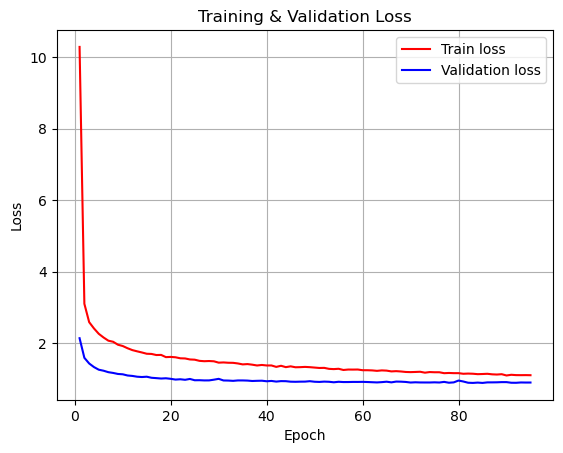

In [47]:
print(history.history.keys()) 

train_loss = history.history["loss"]
val_loss   = history.history["val_loss"]  

epochs = range(1, len(train_loss) + 1)

import matplotlib.pyplot as plt
plt.plot(epochs, train_loss, "r-", label="Train loss")
plt.plot(epochs, val_loss,   "b-", label="Validation loss")
plt.xlabel("Epoch"); plt.ylabel("Loss"); plt.title("Training & Validation Loss")
plt.legend(); plt.grid(True); plt.show()

## 7.2 CNN

A CNN network was employed here as a second trial in order to exploit the inherent 2D structure of the P matrix.
This allows the model to capture potential spatial correlations among matrix elements, while parameter sharing improves training efficiency and mitigates overfitting relative to fully connected architectures.

Train size: 25669, Val size: 6418


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 6, 5, 1)   │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 6, 5, 16)  │        160 │ input_layer_1[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 6, 5, 16)  │         64 │ conv2d[0][0]      │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 6, 5, 32)  │      4,640 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 6, 5, 32)  │        128 │ conv2d_1[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 32)        │          0 │ batch_normalizat… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 32)        │          0 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_layer_2       │ (None, 3)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 35)        │          0 │ dropout_2[0][0],  │
│ (Concatenate)       │                   │            │ input_layer_2[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 64)        │      2,304 │ concatenate[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_3 (Dropout) │ (None, 64)        │          0 │ dense_3[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_4 (Dense)     │ (None, 1)         │         65 │ dropout_3[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 7,361 (28.75 KB)

 Trainable params: 7,265 (28.38 KB)

 Non-trainable params: 96 (384.00 B)

Epoch 1/60
201/201 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 99.7220 - mae: 9.4264 - mse: 99.7174 - val_loss: 64.1870 - val_mae: 7.5500 - val_mse: 64.1824 - learning_rate: 1.0000e-04
Epoch 2/60
201/201 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 44.2949 - mae: 5.8651 - mse: 44.2902 - val_loss: 22.7429 - val_mae: 4.0257 - val_mse: 22.7382 - learning_rate: 1.0000e-04
Epoch 3/60
201/201 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 17.2966 - mae: 3.2665 - mse: 17.2918 - val_loss: 8.4153 - val_mae: 2.1093 - val_mse: 8.4105 - learning_rate: 1.0000e-04
Epoch 4/60
201/201 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 10.3208 - mae: 2.4722 - mse: 10.3159 - val_loss: 5.3721 - val_mae: 1.6806 - val_mse: 5.3673 - learning_rate: 1.0000e-04
Epoch 5/60
201/201 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 8.8009 - mae: 2.3060 - mse: 8.7960 - val_loss: 4.7491 - val_mae: 1.6385 - val_mse: 4.7442 - learning_rate: 1.0000e-04
Epoch 6/60
201/201 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 8.3485 - mae: 2.2555 - mse: 8.3437 - v

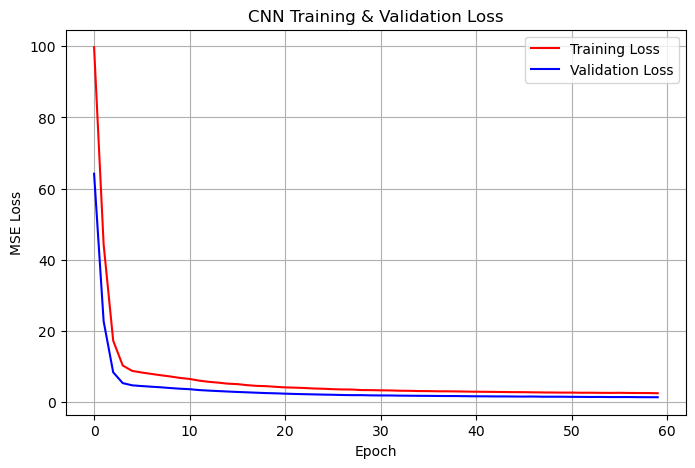

 Saved model to cnn.keras


In [50]:
import numpy as np
import pickle
from sklearn.model_selection import train_test_split
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, regularizers
import matplotlib.pyplot as plt


with open("DS_1_Mheights", "rb") as f:
    teacher_mheights = pickle.load(f)
with open("DS_1_n_k_m_P", "rb") as f:
    teacher_nkmP = pickle.load(f)

with open("MC_calibrated_mheights.pkl", "rb") as f:
    mc_mheights = pickle.load(f)
with open("MC_calibrated_n_k_m_P.pkl", "rb") as f:
    mc_nkmP = pickle.load(f)


def padding_one_P(P, k, n=9):
    P = np.asarray(P, np.float32)
    P_pad = np.zeros((6, 5), dtype=np.float32)
    P_pad[:k, :n-k] = P
    return P_pad


def build_dataset(nkmP_list, mheights):
    X_P, X_scalar, y = [], [], []
    for (n, k, m, P), mh in zip(nkmP_list, mheights):
        P_pad = padding_one_P(P, k, n)
        X_P.append(P_pad)
        X_scalar.append([n, k, m])
        y.append(np.log2(max(mh, 1e-6)))
    return np.array(X_P, np.float32), np.array(X_scalar, np.float32), np.array(y, np.float32)

X_P_teacher, X_scalar_teacher, y_teacher = build_dataset(teacher_nkmP, teacher_mheights)
X_P_mc, X_scalar_mc, y_mc = build_dataset(mc_nkmP, mc_mheights)

# the validation set is only from given dataset, not the MC-calibrated one
X_P_teacher_train, X_P_val, X_scalar_teacher_train, X_scalar_val, y_teacher_train, y_val = \
    train_test_split(X_P_teacher, X_scalar_teacher, y_teacher, test_size=0.2, random_state=42)

# merge training set
'''
X_P_train = np.concatenate([X_P_teacher_train, X_P_mc], axis=0)
X_scalar_train = np.concatenate([X_scalar_teacher_train, X_scalar_mc], axis=0)
y_train = np.concatenate([y_teacher_train, y_mc], axis=0)
'''
X_P_train = np.concatenate([X_P_teacher_train], axis=0)
X_scalar_train = np.concatenate([X_scalar_teacher_train], axis=0)
y_train = np.concatenate([y_teacher_train], axis=0)
print(f"Train size: {len(y_train)}, Val size: {len(y_val)}")


def build_cnn_model():
    input_P = layers.Input(shape=(6, 5, 1))
    input_scalar = layers.Input(shape=(3,))

    x = layers.Conv2D(16, (3, 3), padding='same', activation='relu')(input_P)
    x = layers.BatchNormalization()(x)
    x = layers.Conv2D(32, (3, 3), padding='same', activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dropout(0.3)(x)

    combined = layers.concatenate([x, input_scalar])
    combined = layers.Dense(64, activation='relu', kernel_regularizer=regularizers.l2(1e-4))(combined)
    combined = layers.Dropout(0.3)(combined)
    output = layers.Dense(1, activation='linear')(combined)

    model = keras.Model(inputs=[input_P, input_scalar], outputs=output)
    model.compile(optimizer=keras.optimizers.AdamW(learning_rate=1e-4, weight_decay=1e-5),loss='mse', metrics=['mae', 'mse'])
    return model

model = build_cnn_model()
model.summary()


callbacks = [
    keras.callbacks.EarlyStopping(monitor='val_loss', patience=8, restore_best_weights=True),
    keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=4, min_lr=1e-6)
]

history = model.fit(
    [X_P_train[..., np.newaxis], X_scalar_train], y_train,
    validation_data=([X_P_val[..., np.newaxis], X_scalar_val], y_val),
    epochs=60, batch_size=128, callbacks=callbacks, verbose=1
)


plt.figure(figsize=(8,5))
plt.plot(history.history['loss'], 'r-', label='Training Loss')
plt.plot(history.history['val_loss'], 'b-', label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.title('CNN Training & Validation Loss')
plt.legend()
plt.grid(True)
plt.show()


model.save("cnn.keras")
print(" Saved model to cnn.keras")


dict_keys(['loss', 'mae', 'mse', 'val_loss', 'val_mae', 'val_mse', 'learning_rate'])


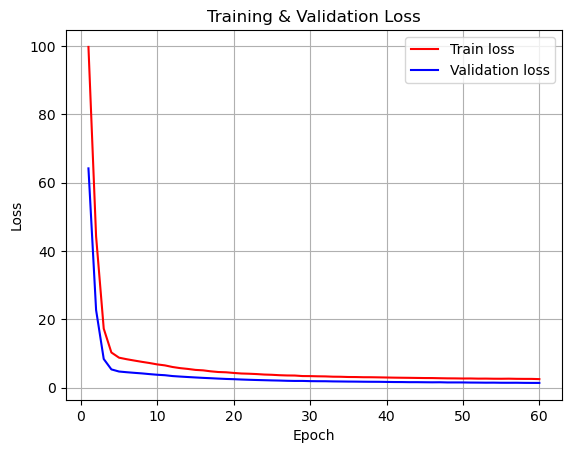

In [51]:
print(history.history.keys()) 

train_loss = history.history["loss"]
val_loss   = history.history["val_loss"]  

epochs = range(1, len(train_loss) + 1)

import matplotlib.pyplot as plt
plt.plot(epochs, train_loss, "r-", label="Train loss")
plt.plot(epochs, val_loss,   "b-", label="Validation loss")
plt.xlabel("Epoch"); plt.ylabel("Loss"); plt.title("Training & Validation Loss")
plt.legend(); plt.grid(True); plt.show()

## 8. Data distribution Analysis


We have only 9 combinations for (k,m). Comparing the (k, m) distributions between the teacher and generated datasets helps verify that the synthetic data covers the same parameter space as the real samples, ensuring distributional consistency and preventing domain shift during model training. Can we make use of that? (show details in next project)

Distribution of (k, m) in teacher dataset:
k=4, m=2: 4109 samples
k=4, m=3: 4007 samples
k=4, m=4: 3689 samples
k=4, m=5: 2374 samples
k=5, m=2: 5007 samples
k=5, m=3: 4633 samples
k=5, m=4: 2887 samples
k=6, m=2: 11546 samples
k=6, m=3: 6147 samples

Distribution of (k, m) in your generated dataset:
k=4, m=2: 1658 samples
k=4, m=3: 1716 samples
k=4, m=4: 1678 samples
k=4, m=5: 1641 samples
k=5, m=2: 2272 samples
k=5, m=3: 2243 samples
k=5, m=4: 2181 samples
k=6, m=2: 3353 samples
k=6, m=3: 3258 samples


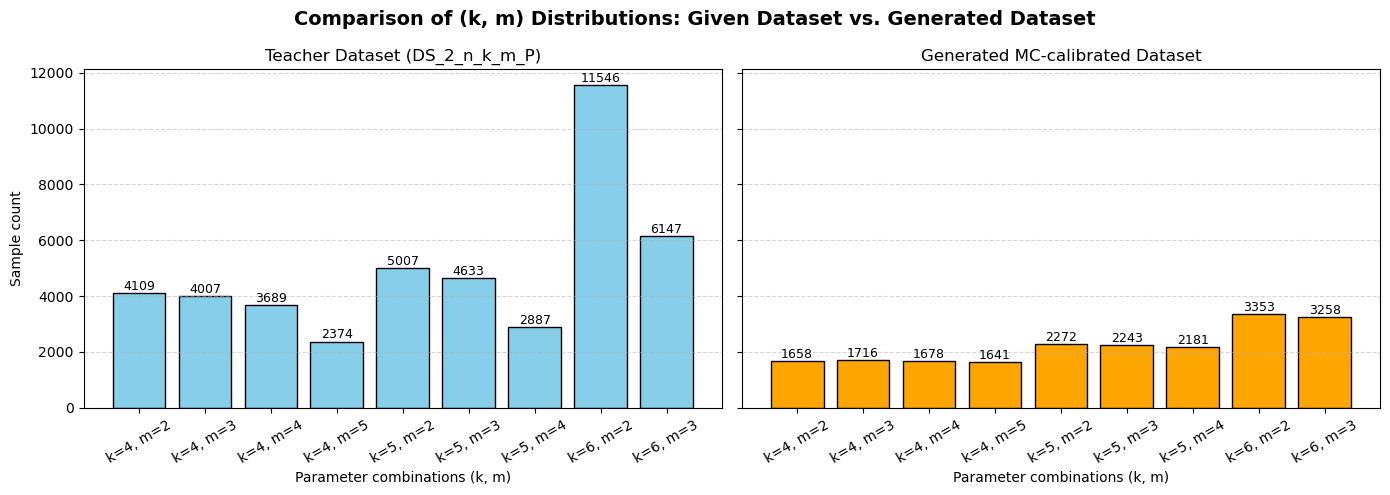

In [54]:
import pickle
import matplotlib.pyplot as plt
from collections import Counter

with open("DS-2-train-n_k_m_P", "rb") as f:
    teacher_nkmP = pickle.load(f)   

#extract (k,m) combinations
km_list_teacher = [(k, m) for (n, k, m, P) in teacher_nkmP]
km_counter_teacher = Counter(km_list_teacher)

print("Distribution of (k, m) in teacher dataset:")
for combo, count in sorted(km_counter_teacher.items()):
    print(f"k={combo[0]}, m={combo[1]}: {count} samples")


with open("calibrated_MC_dataset.pkl", "rb") as f:
    my_data = pickle.load(f)

km_list_my = [(d["k"], d["m"]) for d in my_data]
km_counter_my = Counter(km_list_my)

print("\nDistribution of (k, m) in your generated dataset:")
for combo, count in sorted(km_counter_my.items()):
    print(f"k={combo[0]}, m={combo[1]}: {count} samples")


labels_teacher = [f"k={k}, m={m}" for (k, m) in sorted(km_counter_teacher.keys())]
values_teacher = [km_counter_teacher[(k, m)] for (k, m) in sorted(km_counter_teacher.keys())]

labels_my = [f"k={k}, m={m}" for (k, m) in sorted(km_counter_my.keys())]
values_my = [km_counter_my[(k, m)] for (k, m) in sorted(km_counter_my.keys())]

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

axes[0].bar(labels_teacher, values_teacher, color='skyblue', edgecolor='black')
axes[0].set_title("Teacher Dataset (DS_2_n_k_m_P)", fontsize=12)
axes[0].set_xlabel("Parameter combinations (k, m)")
axes[0].set_ylabel("Sample count")
axes[0].grid(axis='y', linestyle='--', alpha=0.5)
axes[0].tick_params(axis='x', rotation=30)


for bar in axes[0].patches:
    height = bar.get_height()
    axes[0].text(bar.get_x() + bar.get_width()/2, height + 2, f"{int(height)}",
                 ha='center', va='bottom', fontsize=9)


axes[1].bar(labels_my, values_my, color='orange', edgecolor='black')
axes[1].set_title("Generated MC-calibrated Dataset", fontsize=12)
axes[1].set_xlabel("Parameter combinations (k, m)")
axes[1].grid(axis='y', linestyle='--', alpha=0.5)
axes[1].tick_params(axis='x', rotation=30)

for bar in axes[1].patches:
    height = bar.get_height()
    axes[1].text(bar.get_x() + bar.get_width()/2, height + 2, f"{int(height)}",
                 ha='center', va='bottom', fontsize=9)

plt.suptitle("Comparison of (k, m) Distributions: Given Dataset vs. Generated Dataset", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()



## 8. Conclusion

The calibrated MC data performs not well, so we still use the given dataset. And the dense layer seems perform better than the CNN structure. By adding more extracted P matrix features as inputs, the log mse can be reduced to 0.89.

The MLP performed better than the CNN because the underlying assumptions of CNNs do not hold for the P-matrix data. CNNs are designed for spatially structured data such as images, where neighboring pixels are highly correlated and hierarchical local features can be extracted layer by layer (edges → shapes → objects).

However, in the P-matrix, the spatial arrangement of elements does not carry such hierarchical or local meaning. Neighboring entries in the matrix are not more related than distant ones, and permuting the columns of the matrix does not change the underlying physical meaning. As a result, the convolutional operation cannot effectively capture useful local patterns, and the hierarchical feature learning philosophy of CNNs breaks down.

In contrast, MLPs are more suitable for regression problems and for modeling global relationships among all input features. Dense layers can approximate arbitrary nonlinear mappings, as supported by the universal approximation theorem. Wider dense layers often help capture complex relationships, but a larger network also requires a proportionally larger dataset to avoid overfitting.

Therefore, for this regression task based on P-matrix inputs, MLPs are a more appropriate choice than CNNs.

# testdataset

In [8]:
import pickle
test_file = "DS-2-Test-n_k_m_P" 
with open(test_file, "rb") as f:
    test_inputs = pickle.load(f) 

In [39]:
test_X = []
for (n, k, m, P) in test_inputs:
    P_pad = padding_one_P(P, k, n) 
    P_feats = extract_P_features(P_pad)
    x_vec = np.concatenate(([n, k, m], P_pad.flatten(),P_feats))  
    test_X.append(x_vec)
    
test_X = np.array(test_X, dtype=np.float32)
print("Shape of test data:", test_X.shape)

Shape of test data: (10175, 55)


In [43]:
import numpy as np
import pickle
from sklearn.model_selection import train_test_split
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, regularizers
import matplotlib.pyplot as plt

model = keras.models.load_model("log2_NN_best_11.13.keras")  
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ normalization (Normalization)   │ (None, 55)             │           111 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │        14,336 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 142,196 (555.46 KB)

 Trainable params: 47,361 (185.00 KB)

 Non-trainable params: 111 (448.00 B)

 Optimizer params: 94,724 (370.02 KB)

In [47]:
y_pred_log2 = model.predict(test_X).squeeze()
y_pred = np.power(2, y_pred_log2)

318/318 ━━━━━━━━━━━━━━━━━━━━ 0s 216us/step


In [49]:
output_filename = "CSCE 636-600 Fall 2025 Project 2 Test Results Xiaoyun Chu UIN231002795.pkl"
with open(output_filename, "wb") as f:
    pickle.dump(list(y_pred), f)

print("✅ Saved predictions to:", output_filename)

✅ Saved predictions to: CSCE 636-600 Fall 2025 Project 2 Test Results Xiaoyun Chu UIN231002795.pkl


In [59]:
first_input = test_inputs[0]
print("input first sample：")
print("n, k, m =", first_input[0], first_input[1], first_input[2])
print("P shape of samples：", np.array(first_input[3]).shape)
print("P =\n", np.array(first_input[3]))

input first sample：
n, k, m = 9 5 4
P shape of samples： (5, 4)
P =
 [[ 33. -31. -29.  30.]
 [-16. -47. -39.  -1.]
 [-24. -55. -27. -34.]
 [ 17.  46.  40. -17.]
 [ 49.  25. -11. -27.]]


In [65]:
print(y_pred[0])

9918.246


In [67]:

filename = 'CSCE 636-600 Fall 2025 Project 2 Test Results Xiaoyun Chu UIN231002795.pkl'
with open(filename, "rb") as f:
    mheights = pickle.load(f)

mheights = np.array(mheights, dtype=float)

# === Step 2: check if neg values exist ===
neg_mask = mheights < 0
num_neg = np.sum(neg_mask)

if num_neg > 0:
    print(f"⚠️ find {num_neg} 个 m-height < 0")
    print("for example：", mheights[neg_mask][:10])
else:
    print("✅ all m-height  ≥ 0")

print(f"num of samples: {len(mheights)}")
print(f"min value: {mheights.min():.6f}, max: {mheights.max():.6f}, avg: {mheights.mean():.6f}")

✅ all m-height  ≥ 0
num of samples: 10175
min value: 4.994341, max: 78391.804688, avg: 3572.650104
